# Learning OpenStreeMap with Overpass

This is the self guide to understand more how to query locations anywhere in the world with Overpass and Python

In [141]:
!pip install overpass -q
!pip install osmnx -q

In [142]:
# First is to import modules

import os
import json

# importing to make request to overpass API
import requests

from datetime import date

import overpass
import osmnx as ox

In [143]:
# directory in which new dir will be created with a files
dir = r"/data/repo-learning/computer-Science-and-Software-Engineering/real-estate-vis/datasets/raw/2026/overpass-turbo/data"

In [144]:
today = date.today().isoformat()

In [145]:
out_dir = os.path.join(dir, today)

In [146]:
# creating dir if it doesnt exist yet
os.makedirs(out_dir, exist_ok=True)

In [147]:
# setting url where query will be sent
overpass_url = "https://overpass-api.de/api/interpreter"

In [151]:
overpass_url

'https://overpass-api.de/api/interpreter'

## This above did not want to work

Had a problems with getting the data from overpass and any overpass interpreter I used it did not work, so I decided to use osmnx

In [189]:
# importing library
import osmnx as ox

# getting tags from OSM for the location
tags = {"boundary": "administrative", "admin_level": "6"}

# getting osm data for the location that matches the tags
gdf = ox.features_from_place("Las Piñas, Philippines", tags=tags)

# printing it to the screen
gdf.head()


geometry  \
element  id                                                             
node     198515803                          POINT (120.98179 14.4809)   
relation 110365     POLYGON ((121.00945 14.39156, 121.01115 14.396...   
         122129     MULTIPOLYGON (((120.46655 14.3519, 120.47593 1...   
         122139     POLYGON ((120.92284 14.47638, 120.94246 14.492...   
         122940     POLYGON ((120.94026 14.52823, 120.9791 14.5297...   

                   admin_level           name      name:en name:ja name:ko  \
element  id                                                                  
node     198515803           6      Las Piñas    Las Piñas  ラスピニャス   라스피냐스   
relation 110365             10  Ayala Alabang          NaN     NaN     NaN   
         122129              6    Cavite City  Cavite City    カヴィテ     NaN   
         122139              6         Bacoor          NaN     NaN     NaN   
         122940              6      Parañaque    Parañaque  パラニャーケ    파라냐케   

                              name:tl    old_ref place population  ...  \
element  id                                                        ...   
node     198515803          Las Piñas  137601000  city     615549  ...   
relation 110365                   NaN  137603009   NaN      22850  ...   
         122129     Lungsod ng Kabite  042105000   NaN      98673  ...   
         122139                   NaN  042103000   NaN     661381  ...   
         122940             Parañaque  137604000   NaN     689992  ...   

                          boundary note      type related_law barrier  \
element  id                                                             
node     198515803             NaN  NaN       NaN         NaN     NaN   
relation 110365     administrative  NaN  boundary         NaN     NaN   
         122129     administrative  NaN  boundary         NaN     NaN   
         122139     administrative  NaN  boundary         NaN     NaN   
         122940     administrative  NaN  boundary         NaN     NaN   

                   maritime     border_type name:zh-Latn-pinyin land_area  \
element  id                                                                 
node     198515803      NaN             NaN                 NaN       NaN   
relation 110365         NaN        barangay                 NaN       NaN   
         122129         NaN  component_city                 NaN       NaN   
         122139         NaN  component_city                 NaN       NaN   
         122940         NaN            city                 NaN       NaN   

                   addr:postcode  
element  id                       
node     198515803           NaN  
relation 110365              NaN  
         122129              NaN  
         122139              NaN  
         122940              NaN  

[5 rows x 62 columns]

In [191]:

# getting data from table only for the specific location and name
target = "Las Piñas"
name = gdf[gdf["name"] == target]

# printing it to the screen
name

    

,,geometry,admin_level,name,name:en,name:ja,name:ko,name:tl,old_ref,place,population,...,boundary,note,type,related_law,barrier,maritime,border_type,name:zh-Latn-pinyin,land_area,addr:postcode
element,id,,,,,,,,,,,,,,,,,,,,,
node,198515803,POINT (120.98179 14.4809),6,Las Piñas,Las Piñas,ラスピニャス,라스피냐스,Las Piñas,137601000,city,615549,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relation,2095594,"POLYGON ((120.94335 14.49391, 120.94698 14.501...",6,Las Piñas,Las Piñas,ラスピニャス,라스피냐스,Las Piñas,137601000,NaN,615549,...,administrative,NaN,boundary,NaN,NaN,NaN,highly_urbanized_city,NaN,NaN,NaN


## Using Geopandas for visualizing

In [188]:
# importing library
import geopandas as gpd

In [186]:
lp = gdf[gdf["name"] == "Las Piñas"]

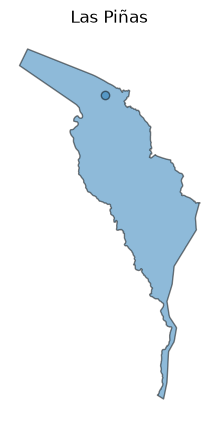

In [193]:
ax = lp.plot(figsize=(5, 5), alpha=0.5, edgecolor="black")
ax.set_title("Las Piñas")

ax.set_axis_off()

In [200]:
# getting tags from OSM for the location
tags = {"boundary": "administrative", "admin_level": "6"}

# getting osm data for the location that matches the tags
gdf = ox.features_from_place("Novi Sad, Serbia", tags=tags)

# printing it to the screen
gdf.head()


geometry  \
element  id                                                           
relation 1279074  POLYGON ((18.81499 45.90941, 18.81798 45.91176...   
         1649671  POLYGON ((18.97128 45.3899, 18.97363 45.39242,...   
         1649672  POLYGON ((19.55636 45.23716, 19.55672 45.23742...   
         9273357  POLYGON ((19.63046 45.29551, 19.63041 45.2978,...   
         9273494  POLYGON ((19.73194 45.30928, 19.73196 45.30928...   

                        boundary                      name  \
element  id                                                  
relation 1279074  administrative                 Војводина   
         1649671  administrative  Јужнобачки управни округ   
         1649672  administrative             Град Нови Сад   
         9273357  administrative                     Футог   
         9273494  administrative                   Руменка   

                                   name:de             name:hu    name:nl  \
element  id                                                                 
relation 1279074                 Wojwodina            Vajdaság  Vojvodina   
         1649671  Bezirk Südliche Batschka  Dél-bácskai körzet        NaN   
         1649672             Stadt Neusatz       Újvidék város        NaN   
         9273357                       NaN                 NaN        NaN   
         9273494                       NaN                 NaN        NaN   

                    name:ro   wikidata                wikipedia admin_level  \
element  id                                                                   
relation 1279074  Voivodina     Q44749             sr:Војводина           4   
         1649671        NaN    Q648718  en:South Bačka District           6   
         1649672        NaN  Q16084152         sr:Град Нови Сад           7   
         9273357        NaN    Q368374                 sr:Футог           9   
         9273494        NaN   Q1049911               sr:Руменка           9   

                  ... name:ce name:kk name:lv name:sq name:tt old_name:hu  \
element  id       ...                                                       
relation 1279074  ...     NaN     NaN     NaN     NaN     NaN         NaN   
         1649671  ...     NaN     NaN     NaN     NaN     NaN         NaN   
         1649672  ...     NaN     NaN     NaN     NaN     NaN         NaN   
         9273357  ...     NaN     NaN     NaN     NaN     NaN         NaN   
         9273494  ...     NaN     NaN     NaN     NaN     NaN         NaN   

                 ref:RS:mesna_zajednica contact:website denomination religion  
element  id                                                                    
relation 1279074                    NaN             NaN          NaN      NaN  
         1649671                    NaN             NaN          NaN      NaN  
         1649672                    NaN             NaN          NaN      NaN  
         9273357                    NaN             NaN          NaN      NaN  
         9273494                    NaN             NaN          NaN      NaN  

[5 rows x 171 columns]

In [203]:
lp = gdf[gdf["name"] == "Град Нови Сад"]

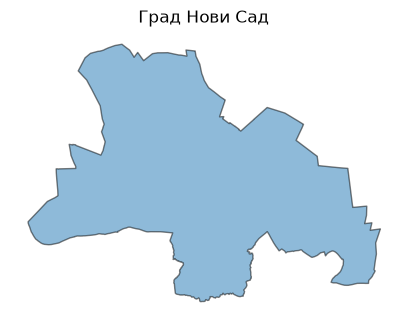

In [204]:
ax = lp.plot(figsize=(5, 5), alpha=0.5, edgecolor="black")
ax.set_title("Град Нови Сад")

ax.set_axis_off()